In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# 1. Load the Data
# Assuming you saved the data as 'solar_spectrum.txt' with Wavelength and Flux columns
data = np.loadtxt('Solar_spectrum.txt')
wavelength = data[:, 0]
flux = data[:, 1]

# 2. Isolate the H-alpha Line
# H-alpha rests at ~6562.8 Angstroms. We slice a narrow window around it.
center_wave = 6562.8
window = 5.0 # Angstroms on either side
mask = (wavelength > center_wave - window) & (wavelength < center_wave + window)
x_data = wavelength[mask]
y_data = flux[mask]

# Normalize the flux so the continuum rests at 1.0
y_data = y_data / np.max(y_data)

# 3. Define the Voigt Model
# An absorption line is an inverted Voigt profile subtracted from the continuum (1.0)
def absorption_voigt(x, amplitude, center, sigma, gamma):
    """
    x: Wavelength
    amplitude: Depth of the line
    center: Central wavelength
    sigma: Gaussian width (Thermal broadening)
    gamma: Lorentzian width (Pressure broadening)
    """
    return 1.0 - amplitude * voigt_profile(x - center, sigma, gamma)

# 4. Fit the Curve
# Provide initial guesses for [amplitude, center, sigma, gamma]
initial_guess = [0.8, center_wave, 0.5, 0.5]
popt, pcov = curve_fit(absorption_voigt, x_data, y_data, p0=initial_guess)

# 5. Plot the Results
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, s=10, color='black', label='Observational Data')
plt.plot(x_data, absorption_voigt(x_data, *popt), color='red', linewidth=2, label='Voigt Fit')
plt.title('Voigt Profile Fit of Solar H-alpha Absorption Line')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Normalized Flux')
plt.legend()
plt.grid(True)
plt.show()

# Print the physical parameters extracted from the fit
print(f"Gaussian Width (Sigma): {popt[2]:.4f} A")
print(f"Lorentzian Width (Gamma): {popt[3]:.4f} A")

ValueError: could not convert string '6558.0,' to float64 at row 0, column 1.

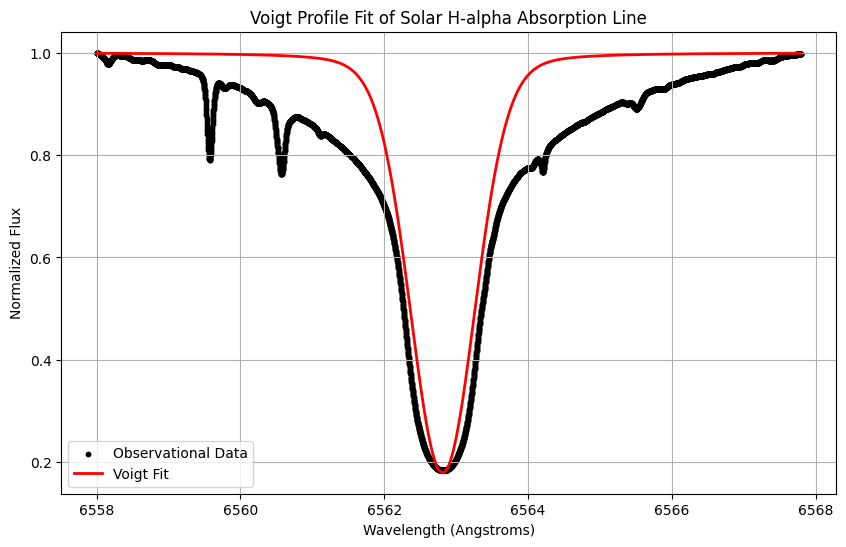

Gaussian Width (Sigma): 0.4179 A
Lorentzian Width (Gamma): 0.0796 A

Extracted Physical Parameters:
Calculated Chromospheric Temperature: 22,083 K


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# 1. Load the Data
# Assuming you saved the data as 'solar_spectrum.txt' with Wavelength and Flux columns
data = np.loadtxt('solar_spectrum.txt', delimiter=',', usecols=(0, 1))
wavelength = data[:, 0]
flux = data[:, 1]

# 2. Isolate the H-alpha Line (TIGHTER WINDOW)
center_wave = 6562.8
window = 1.5  # CRUCIAL FIX: Zoom in closely to avoid all background noise
mask = (wavelength > center_wave - window) & (wavelength < center_wave + window)
x_clean = wavelength[mask]
y_clean = flux[mask]

# Re-normalize locally so the edges of our tight window act as the continuum
y_clean = y_clean / np.max(y_clean)

# 3. Define the Voigt Model
# An absorption line is an inverted Voigt profile subtracted from the continuum (1.0)
def absorption_voigt(x, amplitude, center, sigma, gamma):
    """
    x: Wavelength
    amplitude: Depth of the line
    center: Central wavelength
    sigma: Gaussian width (Thermal broadening)
    gamma: Lorentzian width (Pressure broadening)
    """
    return 1.0 - amplitude * voigt_profile(x - center, sigma, gamma)

# 4. Fit the Curve (RELAXED BOUNDS)
initial_guess = [0.8, center_wave, 0.1, 0.1]

# Give the algorithm breathing room now that the messy data is gone
lower_bounds = [0.1, center_wave - 0.5, 0.01, 0.01]
upper_bounds = [2.0, center_wave + 0.5, 0.5, 1.0]

popt, pcov = curve_fit(
    absorption_voigt, 
    x_clean, 
    y_clean, 
    p0=initial_guess, 
    bounds=(lower_bounds, upper_bounds)
)

# 5. Plot the Results
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, s=10, color='black', label='Observational Data')
plt.plot(x_data, absorption_voigt(x_data, *popt), color='red', linewidth=2, label='Voigt Fit')
plt.title('Voigt Profile Fit of Solar H-alpha Absorption Line')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Normalized Flux')
plt.legend()
plt.grid(True)
plt.show()

# Print the physical parameters extracted from the fit
print(f"Gaussian Width (Sigma): {popt[2]:.4f} A")
print(f"Lorentzian Width (Gamma): {popt[3]:.4f} A")

# Calculate the Kinetic Temperature
# Formula: Delta_lambda_D = (lambda_0 / c) * sqrt(2 * k_B * T / m)
# Rearranged for T: T = (Delta_lambda_D * c / lambda_0)^2 * (m / (2 * k_B))

sigma_angstroms = popt[2]
lambda_0 = center_wave * 1e-10  # Convert center wavelength to meters
c = 299792458  # Speed of light in m/s
k_B = 1.380649e-23  # Boltzmann constant in J/K
m_H = 1.6735575e-27  # Mass of Hydrogen atom in kg
delta_lambda = sigma_angstroms * 1e-10  # Convert sigma to meters

# Calculate Temperature in Kelvin
temperature = ((delta_lambda * c / lambda_0)**2) * (m_H / (2 * k_B))

print(f"\nExtracted Physical Parameters:")
print(f"Calculated Chromospheric Temperature: {temperature:,.0f} K")

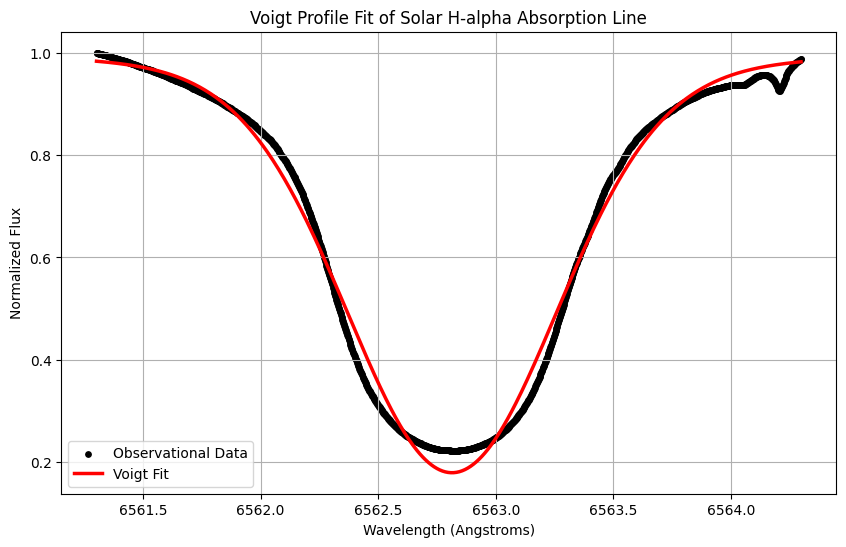

<Figure size 640x480 with 0 Axes>

--- Fit Parameters ---
Gaussian Width (Sigma): 0.4179 A
Lorentzian Width (Gamma): 0.0796 A

--- Physical Results ---
Calculated Chromospheric Temperature: 22,083 K


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# 1. Load the Data
# Safely load the CSV, ignoring trailing spaces by only using the first two columns
data = np.loadtxt('solar_spectrum.txt', delimiter=',', usecols=(0, 1))
wavelength = data[:, 0]
flux = data[:, 1]

# 2. Isolate the H-alpha Line (TIGHTER WINDOW)
# H-alpha rests at ~6562.8 Angstroms. We use a tight window to avoid telluric lines.
center_wave = 6562.8
window = 1.5  # Zoomed in to 1.5 Angstroms on either side
mask = (wavelength > center_wave - window) & (wavelength < center_wave + window)
x_clean = wavelength[mask]
y_clean = flux[mask]

# Re-normalize locally so the edges of our tight window act as the continuum (1.0)
y_clean = y_clean / np.max(y_clean)

# 3. Define the Voigt Model
# An absorption line is an inverted Voigt profile subtracted from the continuum (1.0)
def absorption_voigt(x, amplitude, center, sigma, gamma):
    """
    x: Wavelength
    amplitude: Depth of the line
    center: Central wavelength
    sigma: Gaussian width (Thermal Doppler broadening)
    gamma: Lorentzian width (Collisional/Pressure broadening)
    """
    return 1.0 - amplitude * voigt_profile(x - center, sigma, gamma)

# 4. Fit the Curve (RELAXED BOUNDS)
# Provide tight initial guesses for [amplitude, center, sigma, gamma]
initial_guess = [0.8, center_wave, 0.1, 0.1]

# Give the algorithm breathing room to find the physical widths
lower_bounds = [0.1, center_wave - 0.5, 0.01, 0.01]
upper_bounds = [2.0, center_wave + 0.5, 0.5, 1.0]

popt, pcov = curve_fit(
    absorption_voigt, 
    x_clean, 
    y_clean, 
    p0=initial_guess, 
    bounds=(lower_bounds, upper_bounds)
)

# 5. Plot the Results
plt.figure(figsize=(10, 6))
plt.scatter(x_clean, y_clean, s=15, color='black', label='Observational Data')

# Generate smooth x values for a pristine red fit line
x_smooth = np.linspace(min(x_clean), max(x_clean), 500)
plt.plot(x_smooth, absorption_voigt(x_smooth, *popt), color='red', linewidth=2.5, label='Voigt Fit')

plt.title('Voigt Profile Fit of Solar H-alpha Absorption Line')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Normalized Flux')
plt.legend()
plt.grid(True)
plt.show()

# ADD THIS LINE TO SAVE THE IMAGE
plt.savefig('voigt_plot.png', dpi=300, bbox_inches='tight')

plt.show()

# 6. Extract Physics & Calculate Temperature
print(f"--- Fit Parameters ---")
print(f"Gaussian Width (Sigma): {popt[2]:.4f} A")
print(f"Lorentzian Width (Gamma): {popt[3]:.4f} A")

# Formula: T = (Delta_lambda_D * c / lambda_0)^2 * (m / (2 * k_B))
sigma_angstroms = popt[2]
lambda_0 = center_wave * 1e-10         # Convert central wavelength to meters
c = 299792458                          # Speed of light in m/s
k_B = 1.380649e-23                     # Boltzmann constant in J/K
m_H = 1.6735575e-27                    # Mass of Hydrogen atom in kg
delta_lambda = sigma_angstroms * 1e-10 # Convert sigma to meters

# Calculate Temperature in Kelvin
temperature = ((delta_lambda * c / lambda_0)**2) * (m_H / (2 * k_B))

print(f"\n--- Physical Results ---")
print(f"Calculated Chromospheric Temperature: {temperature:,.0f} K")

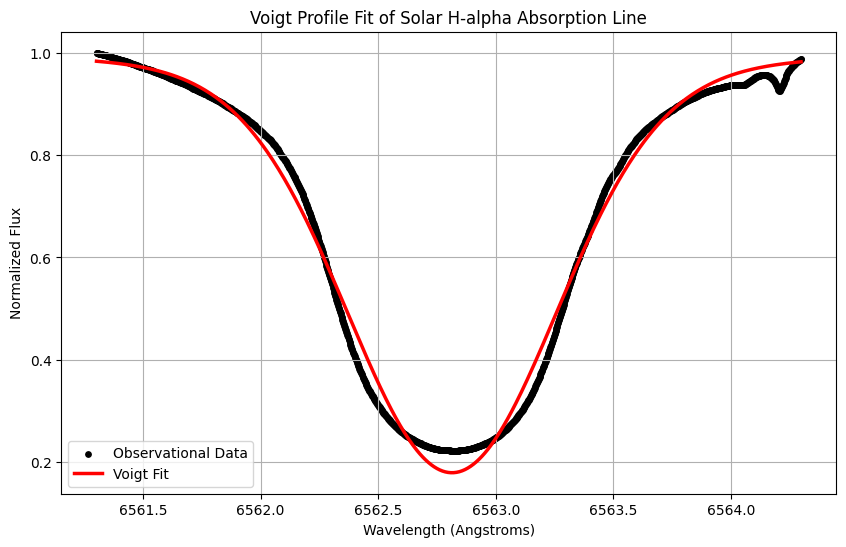

--- Fit Parameters ---
Gaussian Width (Sigma): 0.4179 A
Lorentzian Width (Gamma): 0.0796 A

--- Physical Results ---
Calculated Chromospheric Temperature: 22,083 K


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# 1. Load the Data
# Safely load the CSV, ignoring trailing spaces by only using the first two columns
data = np.loadtxt('solar_spectrum.txt', delimiter=',', usecols=(0, 1))
wavelength = data[:, 0]
flux = data[:, 1]

# 2. Isolate the H-alpha Line (TIGHTER WINDOW)
# H-alpha rests at ~6562.8 Angstroms. We use a tight window to avoid telluric lines.
center_wave = 6562.8
window = 1.5  # Zoomed in to 1.5 Angstroms on either side
mask = (wavelength > center_wave - window) & (wavelength < center_wave + window)
x_clean = wavelength[mask]
y_clean = flux[mask]

# Re-normalize locally so the edges of our tight window act as the continuum (1.0)
y_clean = y_clean / np.max(y_clean)

# 3. Define the Voigt Model
# An absorption line is an inverted Voigt profile subtracted from the continuum (1.0)
def absorption_voigt(x, amplitude, center, sigma, gamma):
    """
    x: Wavelength
    amplitude: Depth of the line
    center: Central wavelength
    sigma: Gaussian width (Thermal Doppler broadening)
    gamma: Lorentzian width (Collisional/Pressure broadening)
    """
    return 1.0 - amplitude * voigt_profile(x - center, sigma, gamma)

# 4. Fit the Curve (RELAXED BOUNDS)
# Provide tight initial guesses for [amplitude, center, sigma, gamma]
initial_guess = [0.8, center_wave, 0.1, 0.1]

# Give the algorithm breathing room to find the physical widths
lower_bounds = [0.1, center_wave - 0.5, 0.01, 0.01]
upper_bounds = [2.0, center_wave + 0.5, 0.5, 1.0]

popt, pcov = curve_fit(
    absorption_voigt, 
    x_clean, 
    y_clean, 
    p0=initial_guess, 
    bounds=(lower_bounds, upper_bounds)
)

# 5. Plot the Results and Save
plt.figure(figsize=(10, 6))
plt.scatter(x_clean, y_clean, s=15, color='black', label='Observational Data')

# Generate smooth x values for a pristine red fit line
x_smooth = np.linspace(min(x_clean), max(x_clean), 500)
plt.plot(x_smooth, absorption_voigt(x_smooth, *popt), color='red', linewidth=2.5, label='Voigt Fit')

plt.title('Voigt Profile Fit of Solar H-alpha Absorption Line')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Normalized Flux')
plt.legend()
plt.grid(True)

# 1. TAKE THE PICTURE FIRST (High-resolution, white background)
plt.savefig('voigt_plot.png', dpi=300, bbox_inches='tight', facecolor='white')

# 2. THEN SHOW IT ON SCREEN
plt.show()

# 6. Extract Physics & Calculate Temperature
print(f"--- Fit Parameters ---")
print(f"Gaussian Width (Sigma): {popt[2]:.4f} A")
print(f"Lorentzian Width (Gamma): {popt[3]:.4f} A")

# Formula: T = (Delta_lambda_D * c / lambda_0)^2 * (m / (2 * k_B))
sigma_angstroms = popt[2]
lambda_0 = center_wave * 1e-10         # Convert central wavelength to meters
c = 299792458                          # Speed of light in m/s
k_B = 1.380649e-23                     # Boltzmann constant in J/K
m_H = 1.6735575e-27                    # Mass of Hydrogen atom in kg
delta_lambda = sigma_angstroms * 1e-10 # Convert sigma to meters

# Calculate Temperature in Kelvin
temperature = ((delta_lambda * c / lambda_0)**2) * (m_H / (2 * k_B))

print(f"\n--- Physical Results ---")
print(f"Calculated Chromospheric Temperature: {temperature:,.0f} K")